## Feature Extraction

### Importy

In [31]:
from __future__ import annotations

import cv2
import numpy as np
from pathlib import Path


from coronary_analysis.utils import show_image

import torch
from coronary_analysis.models.segmentation import CoronaryUNet
from coronary_analysis.transforms.transforms import get_val_transforms

### Konfiguracja zmiennych środowiskowych

In [32]:
USE_GROUND_TRUTH: bool = False
SAMPLE_ID: int = 2
DCA1_DIR = Path("raw_datasets/DCA1/Database_134_Angiograms")
MODEL_PATH = Path("../models/best_coronary_unet.pth")
IMG_SIZE: int = 250
THRESHOLD: float = 0.5
MIN_OBJECT_SIZE: int = 50
MAX_HOLE_SIZE: int = 50
CLOSING_DISK_RADIUS: int = 1

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## Wczytanie danych

### Wczytanie pliku PGM w skali szarości

In [33]:
def _load_pgm(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise FileNotFoundError(f"File not found: {path}")

    return image

### Wczytanie obrazu oraz binaryzacja

In [34]:
def load_sample(
    sample_id: int, ground_truth: bool = True
) -> tuple[np.ndarray, np.ndarray]:
    image = _load_pgm(DCA1_DIR / f"{sample_id}.pgm")

    if ground_truth:
        raw = _load_pgm(DCA1_DIR / f"{sample_id}_gt.pgm")
        mask = (raw > 0).astype(np.uint8)
    else:
        mask = _predict_mask(image)

    return image, mask

### Uruchomienie modelu segmentacji i zwrócenie maski binarnej

In [35]:
def _predict_mask(image: np.ndarray) -> np.ndarray:
    model = CoronaryUNet(encoder_name="resnet34").to(device)
    state = torch.load(str(MODEL_PATH), map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.eval()

    transform = get_val_transforms(IMG_SIZE)
    augmented = transform(image=image, mask=np.zeros_like(image))

    img_tensor = (
        torch.from_numpy(augmented["image"]).float().unsqueeze(0).unsqueeze(0) / 255.0
    ).to(device)

    with torch.no_grad():
        probs = model.predict_proba(img_tensor)
        pred = (probs > THRESHOLD).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    h, w = image.shape[:2]
    if pred_np.shape != (h, w):
        pred_np = cv2.resize(pred_np, (w, h), interpolation=cv2.INTER_NEAREST)

    return pred_np

### Wizualizacja wczytanych danych

Image: shape=(300, 300), dtype=uint8
Mask: shape=(300, 300), dtype=uint8, unique=[0 1]


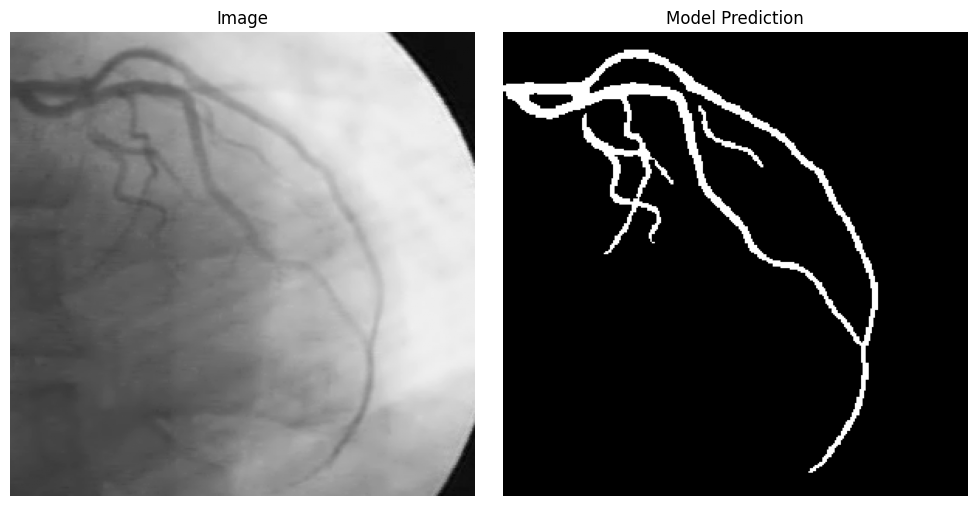

In [36]:
image, raw_mask = load_sample(SAMPLE_ID, ground_truth=USE_GROUND_TRUTH)

source_label = "Ground Truth" if USE_GROUND_TRUTH else "Model Prediction"

print(f"Image: shape={image.shape}, dtype={image.dtype}")
print(
    f"Mask: shape={raw_mask.shape}, dtype={raw_mask.dtype}, "
    f"unique={np.unique(raw_mask)}"
)

show_image(image, raw_mask, titles=["Image", source_label])